<a href="https://colab.research.google.com/github/edwardsnj/glygen-colab-notebooks/blob/main/variants/main2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import httpimport, sys, os, os.path

for key in list(sys.modules):
  if key.startswith("variants."):
    del sys.modules[key]

with httpimport.github_repo("edwardsnj", "glygen-colab-notebooks", ref="dfc6002"):
  from glygen import GlyGenDownloader
  from variants import extract_datasets, make_plotdata, map_datasets, run_binomial_test

# create directories if necessary
for dirname in ("data","reviewed","plots"):
  if not os.path.exists(dirname):
    os.mkdir(dirname)

human_protein_mutation_files = """
  human_protein_mutation_cancer_all.csv
  human_protein_mutation_germline_all.csv
"""

human_proteoform_glycosylation_site_files = """
  human_proteoform_glycosylation_sites_carbbank.csv
  human_proteoform_glycosylation_sites_c_man.csv
  human_proteoform_glycosylation_sites_diabetes_glycomic.csv
  human_proteoform_glycosylation_sites_embl.csv
  human_proteoform_glycosylation_sites_glycomeatlas.csv
  human_proteoform_glycosylation_sites_glyconnect.csv
  human_proteoform_glycosylation_sites_gptwiki.csv
  human_proteoform_glycosylation_sites_harvard.csv
  human_proteoform_glycosylation_sites_literature.csv
  human_proteoform_glycosylation_sites_literature_mining.csv
  human_proteoform_glycosylation_sites_literature_mining_manually_verified.csv
  human_proteoform_glycosylation_sites_oglcnac_atlas.csv
  human_proteoform_glycosylation_sites_oglcnac_mcw.csv
  human_proteoform_glycosylation_sites_o_gluc.csv
  human_proteoform_glycosylation_sites_o_gluc_predicted.csv
  human_proteoform_glycosylation_sites_pdb.csv
  human_proteoform_glycosylation_sites_pdc_ccrcc.csv
  human_proteoform_glycosylation_sites_platelet.csv
  human_proteoform_glycosylation_sites_predicted_isoglyp.csv
  human_proteoform_glycosylation_sites_rcsb_pdb.csv
  human_proteoform_glycosylation_sites_tablemaker.csv
  human_proteoform_glycosylation_sites_twinsuk.csv
  human_proteoform_glycosylation_sites_tyr_o_linked.csv
  human_proteoform_glycosylation_sites_unicarbkb.csv
  human_proteoform_glycosylation_sites_unicarbkb_glycomics_study.csv
  human_proteoform_glycosylation_sites_uniprotkb.csv
"""

ggdl = GlyGenDownloader()
for fn in human_protein_mutation_files.split() + \
          human_proteoform_glycosylation_site_files.split():
  ggdl.download(fn,"reviewed")

Using cached human_protein_mutation_cancer_all.csv (915.15 MB).
Using cached human_protein_mutation_germline_all.csv (10.57 GB).
Using cached human_proteoform_glycosylation_sites_carbbank.csv (839.00 B).
Using cached human_proteoform_glycosylation_sites_c_man.csv (46.86 KB).
Using cached human_proteoform_glycosylation_sites_diabetes_glycomic.csv (604.89 KB).
Using cached human_proteoform_glycosylation_sites_embl.csv (1.60 MB).
Using cached human_proteoform_glycosylation_sites_glycomeatlas.csv (82.51 KB).
Using cached human_proteoform_glycosylation_sites_glyconnect.csv (11.12 MB).
Using cached human_proteoform_glycosylation_sites_gptwiki.csv (384.62 KB).
Using cached human_proteoform_glycosylation_sites_harvard.csv (149.59 KB).
Using cached human_proteoform_glycosylation_sites_literature.csv (1.89 MB).
Using cached human_proteoform_glycosylation_sites_literature_mining.csv (220.01 KB).
Using cached human_proteoform_glycosylation_sites_literature_mining_manually_verified.csv (26.10 KB).


In [32]:
#
# Parameters for the figure
#

# SITETYPE = "predicted"
SITETYPE = "experimental"

# VARTYPE = "somatic_cancer"
# VARTYPE = "germline"

GLYCOTYPE = "N-linked"
# GLYCOTYPE = "O-linked"

In [33]:
extract_datasets.REVIEWED_DIR = "reviewed"
extract_datasets.data_dir = "data"
extract_datasets.extract_glyco_sites()
extract_datasets.extract_variants()


=== FILE ROUTING ===
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_diabetes_glycomic.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_o_gluc.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_unicarbkb_glycomics_study.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_tyr_o_linked.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_literature.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_unicarbkb.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_harvard.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_tablemaker.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_c_man.csv
PREDICTED: reviewed/human_proteoform_glycosylation_sites_predicted_isoglyp.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_embl.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_glycomeatlas.csv
EXPERIMENTAL: reviewed/human_proteoform_glycosylation_sites_literat

In [34]:
map_datasets.DATA_DIR = "data"
sys.argv = ["map_datasets.py",
            "--glycotype",GLYCOTYPE,
            "--vartype","germline",
            "--sitetype",SITETYPE]
map_datasets.main()
sys.argv = ["map_datasets.py",
            "--glycotype",GLYCOTYPE,
            "--vartype","somatic_cancer",
            "--sitetype",SITETYPE]
map_datasets.main()


In [35]:
run_binomial_test.DATA_DIR = "data"
sys.argv = ["run_binomial_test.py","-a"]
run_binomial_test.main()

Found 2 mapping file(s) to process
Processing: data/mapping.human.n_linked.germline_experimental.csv
-20 6281
-19 6284
-18 6249
-17 6327
-16 6278
-15 6277
-14 6249
-13 6270
-12 6302
-11 6313
-10 6297
-9 6270
-8 6297
-7 6309
-6 6313
-5 6308
-4 6423
-3 6381
-2 6382
-1 6367
0 6554
1 6194
2 6305
3 6338
4 6238
5 6306
6 6304
7 6364
8 6205
9 6251
10 6229
11 6293
12 6247
13 6274
14 6335
15 6236
16 6235
17 6223
18 6209
19 6229
20 6179
N 257925
Written: data/binomial_test.mapping.human.n_linked.germline_experimental.csv
Processing: data/mapping.human.n_linked.somatic_cancer_experimental.csv
-20 2943
-19 3076
-18 2945
-17 2980
-16 3049
-15 3015
-14 3076
-13 3026
-12 3027
-11 3017
-10 3076
-9 3008
-8 3112
-7 2977
-6 3072
-5 2975
-4 2959
-3 3104
-2 2790
-1 3104
0 1806
1 3200
2 2892
3 3006
4 2982
5 2994
6 3081
7 3014
8 2958
9 3026
10 2937
11 3020
12 3061
13 2966
14 3034
15 2932
16 2913
17 2983
18 2905
19 2999
20 2869
N 121909
Written: data/binomial_test.mapping.human.n_linked.somatic_cancer_experime


Files found for plotting:
  data/mapping.human.n_linked.germline_experimental.csv

Plot data written: plots/plotdata.human.n_linked.germline_experimental.json
Plot saved: plots/plot.human.n_linked.germline_experimental.png

Files found for plotting:
  data/mapping.human.n_linked.germline_experimental.csv
  data/mapping.human.n_linked.somatic_cancer_experimental.csv

Plot data written: plots/plotdata.human.n_linked.all_experimental.json
Plot saved: plots/plot.human.n_linked.all_experimental.png


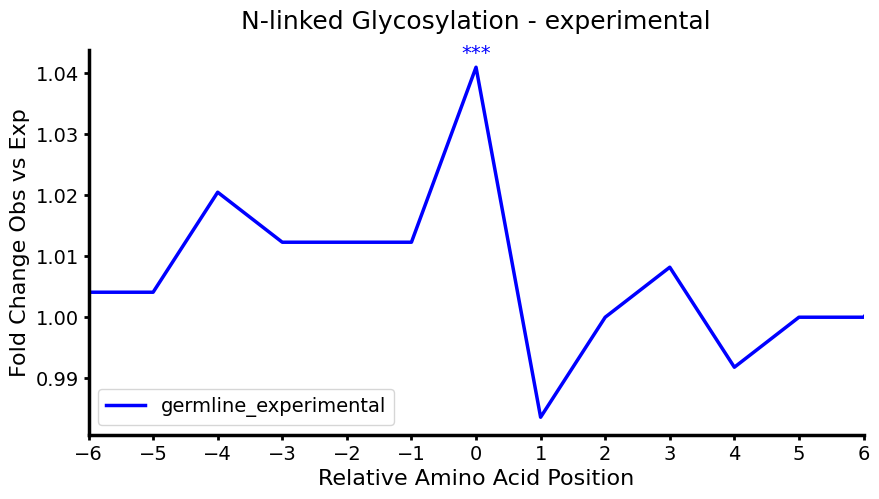

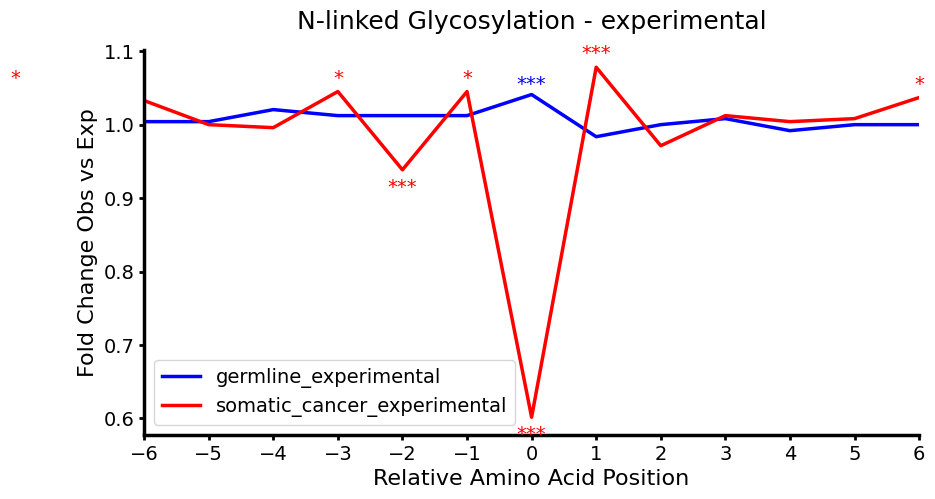

In [36]:
make_plotdata.DATA_DIR = "data"
make_plotdata.PLOTS_DIR = "plots"
sys.argv = ["make_plotdata.py",
            "--glycotype",GLYCOTYPE,
            "--vartype","germline",
            "--sitetype",SITETYPE]
make_plotdata.main()
sys.argv = ["make_plotdata.py",
            "--glycotype",GLYCOTYPE,
            "--vartype","somatic_cancer",
            "--sitetype",SITETYPE]
make_plotdata.main()